# **Вариант №18**

2) Выполните отделение корней графически и найдите один из корней методами простой итерации и Ньютона с абсолютной погрешностью 0,0001.
$$\tan(0.55x+0.1) = x^2$$


Подключаем библиотеки:

In [2]:
from typing import Callable
from dataclasses import dataclass, asdict
from math import log, e, cos, tan, sqrt, atan

import matplotlib.pyplot as plt
import numpy as np

Прописываем классы для удобной работы ввода и вывода данных

In [3]:
@dataclass
class Result:
    x: float
    fx: float
    count_iter: int

    def __str__(self):
        return f"x = {self.x}, f(x) = {self.fx}, iter = {self.count_iter}"


@dataclass
class Example:
    func: Callable[[float], float]
    a: int
    b: int
    epsilon: float = 10e-5
    max_iteration: float = 10_000

    def to_dict(self) -> dict:
        return asdict(self)

    def __str__(self) -> str:
        return f"Example: a = {self.a}, b = {self.b}, \
epsilon = {self.epsilon}, max iteration = {self.max_iteration}"


@dataclass
class ExampleSimpleIter:
    phi: Callable[[float], float]
    a: int
    b: int
    x0: int = None
    epsilon: float = 10e-5
    max_iteration: float = 10_000

    def to_dict(self) -> dict:
        return asdict(self)

    def __str__(self) -> str:
        return f"Example: a = {self.a}, b = {self.b}, x0 = {self.x0},\
epsilon = {self.epsilon}, max iteration = {self.max_iteration}"


@dataclass
class ExampleNewton:
    func: Callable[[float], float]
    func_prime: Callable[[float], float]
    a: int
    b: int
    x0: int = None
    epsilon: float = 10e-5
    max_iteration: float = 10_000

    def to_dict(self) -> dict:
        return asdict(self)

    def __str__(self) -> str:
        return f"Example: a = {self.a}, b = {self.b}, x0 = {self.x0},\
epsilon = {self.epsilon}, max iteration = {self.max_iteration}"

Метод простых итераций

In [37]:
def method_simple_iteration(
    phi: Callable[[float], float],
    a: float,
    b: float,
    x0: float = None,
    epsilon: float = 10e-6,
    max_iteration: int = 10000,
) -> Result:
    # Если точка не задана, то расположим ее в центре отрезка
    if x0 is None:
        x0 = (a + b) / 2

    x_current = x0

    for i in range(max_iteration):
        x_next = phi(x_current)

        if abs(x_next - x_current) < epsilon:
            return Result(x_next, np.tan(x_next * 0.55 + 0.1) - x_next**2, i)

        if not (a <= x_next <= b):
            raise ValueError("Вычисления вышли за границы отрезка")

        x_current = x_next

    # В случае, если пересечение не было найдено за отведенное количество итераций, то
    # выдаем соответствующую ошибку
    raise RuntimeError(
        f"Нахождение корня превысило количество допустимых итераций ({max_iteration=})"
    )

Метод Ньютона

In [38]:
def method_newton(
    func: Callable[[float], float],
    func_prime: Callable[[float], float],
    a: float,
    b: float,
    x0: float = None,
    epsilon: float = 10e-6,
    max_iteration: int = 10000,
) -> Result:  # Возвращаем Result, а не float
    # Находим значения функции в точках границ отрезка
    fa, fb = func(a), func(b)

    # Проверка смены знака на концах отрезка
    if fa * fb >= 0:
        raise ValueError("На концах отрезка функция должна иметь разные знаки")

    # Если точка не задана, то расположим ее в центре отрезка
    if x0 is None:
        x0 = (a + b) / 2

    x_cur = x0

    for iter in range(max_iteration):
        # Проверка деления на ноль
        f_prime = func_prime(x_cur)
        if abs(f_prime) < 1e-15:
            raise ValueError("Производная близка к нулю, метод Ньютона не сходится")

        x_next = x_cur - func(x_cur) / f_prime

        # Проверка выхода за границы отрезка
        if not (a <= x_next <= b):
            raise ValueError("Вычисления вышли за границы отрезка")

        if abs(x_next - x_cur) < epsilon or abs(func(x_next)) < epsilon:
            return Result(x_next, func(x_next), iter + 1)  # Возвращаем Result

        x_cur = x_next

    # В случае, если пересечение не было найдено за отведенное количество итераций, то
    # выдаем соответствующую ошибку
    raise RuntimeError(
        f"Нахождение корня превысило количество допустимых итераций ({max_iteration=})"
    )

Создание объектов задания для тестирования

Для метода Ньютона находим $f'(x)$:

$$f'(x) = \left(\tan(0.55x+0.1) - x^2\right)'_x = 0.55 \cdot\sec (0.55x+0.1)^2 - 2x = \boxed{\frac{0.55}{\cos(0.55x+0.1)^2} - 2x}$$

Для метода простых итераций находим функцию, эквивалентную $f(x) = 0$, а именно $\varphi(x) = x$:
$$\tan(0.55x+0.1) - x^2 = 0$$
$$\tan(0.55x+0.1) = x^2$$
$$0.55x+0.1 = \arctan(x^2) + \pi k, \, k \in \mathbb{Z}$$
$$\boxed{x = \frac{\arctan(x^2) - 0.1}{0.55}, \text{ при $k = 0$}}$$

In [42]:
task_simple_iteration = ExampleSimpleIter(
    phi=lambda x: (np.atan(x**2) - 0.1) / 0.55, a=-1, b=0, x0=-0.2, epsilon=0.0001
)

task_newton = ExampleNewton(
    func=lambda x: np.tan(0.55 * x + 0.1) - x**2,
    func_prime=lambda x: 0.55 / np.cos(0.55 * x + 0.1) ** 2 - 2 * x,
    a=-1,
    b=0,
)

Проверка метода простых итераций

In [43]:
result = None

try:
    result = method_simple_iteration(**task_simple_iteration.to_dict())
except Exception as ex:
    print(ex)

print("Метод простых итераций:", result)

Метод простых итераций: x = -0.14410571762280078, f(x) = -2.1627480274778038e-05, iter = 11


Проверка метода Ньютона

In [44]:
result = None

try:
    result = method_newton(**task_newton.to_dict())
except Exception as ex:
    print(ex)

print("Метод Ньютона:", result)

Метод Ньютона: x = -0.14413656446286174, f(x) = -4.74919010920935e-05, iter = 3


Построим графики функций

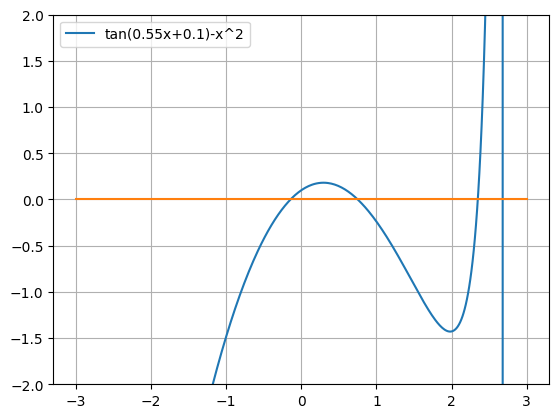

In [45]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-3, 3, 400)
plt.plot(x, task_newton.func(x), label="tan(0.55x+0.1)-x^2")
plt.plot(x, np.zeros(x.size))
plt.grid(True)
plt.legend()
plt.ylim(-2, 2)
plt.show()

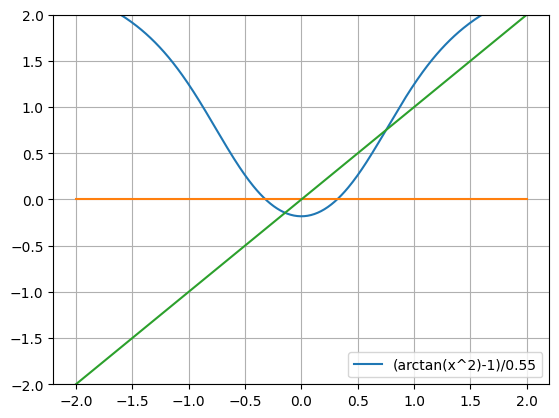

In [75]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-2, 2, 400)
plt.plot(x, task_simple_iteration.phi(x), label="(arctan(x^2)-1)/0.55")
plt.plot(x, np.zeros(x.size))
plt.plot(x, x)
plt.grid(True)
plt.legend()
plt.ylim(-2, 2)
plt.show()